<a href="https://colab.research.google.com/github/partha-pkp/data-mining-drug-discovery/blob/main/avanie/Rotation_Screening.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================================================
# 1) INSTALLS + IMPORTS + HELPERS
# =========================================================

!pip -q install aeon scikit-learn liac-arff

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import arff

from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score,
    roc_curve, roc_auc_score, classification_report
)

from aeon.classification.sklearn import RotationForestClassifier


# -------------------------------
# Full classification report
# -------------------------------
def print_full_metrics(y_true, y_pred, title="Model"):
    print("\n" + "=" * 70)
    print(f"FULL METRICS: {title}")
    print("=" * 70)

    print(classification_report(
        y_true,
        y_pred,
        target_names=["Non-Senolytic (0)", "Senolytic (1)"],
        digits=4,
        zero_division=0
    ))


# -------------------------------
# Threshold selection
# -------------------------------
def threshold_for_target_recall(y_true, y_prob, target_recall=0.80):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)

    precisions_t = precisions[:-1]
    recalls_t = recalls[:-1]

    valid = np.where(recalls_t >= target_recall)[0]
    if len(valid) == 0:
        return None

    best_idx = valid[np.argmax(precisions_t[valid])]
    return thresholds[best_idx]


def threshold_for_target_recall_safe(y_true, y_prob, target_recall=0.80, min_threshold=0.05):
    """
    Keeps recall >= target_recall, but prevents collapse to near-zero thresholds.
    """
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)

    precisions_t = precisions[:-1]
    recalls_t = recalls[:-1]

    valid = np.where((recalls_t >= target_recall) & (thresholds >= min_threshold))[0]
    if len(valid) == 0:
        return None

    best_idx = valid[np.argmax(precisions_t[valid])]
    return thresholds[best_idx]


# -------------------------------
# Evaluation at a threshold
# -------------------------------
def evaluate_at_threshold(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "avg_precision": average_precision_score(y_true, y_prob),
        "cm": confusion_matrix(y_true, y_pred),
        "y_pred": y_pred
    }


# -------------------------------
# Rotation Forest builder
# -------------------------------
def make_rotation_forest(class_weight, n_estimators, min_group, max_group, remove_proportion, max_depth=None):
    base_tree = DecisionTreeClassifier(
        criterion="entropy",
        class_weight=class_weight,
        max_depth=max_depth,
        random_state=42
    )

    return RotationForestClassifier(
        n_estimators=n_estimators,
        min_group=min_group,
        max_group=max_group,
        remove_proportion=remove_proportion,
        base_estimator=base_tree,
        random_state=42,
        n_jobs=-1
    )

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 12.6 MB/s eta 0:00:00


In [ ]:
# =========================================================
# 2) LOAD LABELED TRAINING DATA
# =========================================================

from google.colab import files

uploaded = files.upload()
ARFF_FILE = list(uploaded.keys())[0]

data, meta = arff.loadarff(ARFF_FILE)
df = pd.DataFrame(data)

TARGET_COL = "senolytic"
df[TARGET_COL] = df[TARGET_COL].str.decode("utf-8").astype(int)

X = df.drop(columns=[TARGET_COL]).copy()
y = df[TARGET_COL].copy()

print("Loaded labeled dataset:", df.shape)
print("Feature matrix shape:", X.shape)
print("Positive count:", int(y.sum()))
print("Negative count:", int((y == 0).sum()))
print("Positive rate:", y.mean())

Saving input_data_no_smiles.arff to input_data_no_smiles.arff
Loaded labeled dataset: (4866, 201)
Feature matrix shape: (4866, 200)
Positive count: 103
Negative count: 4763
Positive rate: 0.02116728318947801


In [ ]:
# =========================================================
# 3) FIT FINAL BEST ROTATION FOREST
# =========================================================

BEST_THRESHOLD = 0.058508

imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

final_rotf = make_rotation_forest(
    class_weight="balanced",
    n_estimators=200,
    min_group=3,
    max_group=3,
    remove_proportion=0.5,
    max_depth=10
)

final_rotf.fit(X_imputed, y)

print("Final Rotation Forest fit complete.")
print("Threshold to use for screening:", BEST_THRESHOLD)

Final Rotation Forest fit complete.
Threshold to use for screening: 0.058508


In [ ]:
# =========================================================
# 4) LOAD COMPUTATIONAL SCREENING DATASET
# =========================================================

uploaded = files.upload()
screen_file = list(uploaded.keys())[0]

screen_df = pd.read_csv(screen_file)

print("Screening dataset shape:", screen_df.shape)
print("\nColumns:")
print(screen_df.columns.tolist())

screen_df.head()

Saving computational_screening_results.csv to computational_screening_results.csv
Screening dataset shape: (4340, 205)

Columns:
['Name', 'Library', 'SMILES', 'BalabanJ', 'BertzCT', 'Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi1n', 'Chi1v', 'Chi2n', 'Chi2v', 'Chi3n', 'Chi3v', 'Chi4n', 'Chi4v', 'EState_VSA1', 'EState_VSA10', 'EState_VSA11', 'EState_VSA2', 'EState_VSA3', 'EState_VSA4', 'EState_VSA5', 'EState_VSA6', 'EState_VSA7', 'EState_VSA8', 'EState_VSA9', 'ExactMolWt', 'FpDensityMorgan1', 'FpDensityMorgan2', 'FpDensityMorgan3', 'FractionCSP3', 'HallKierAlpha', 'HeavyAtomCount', 'HeavyAtomMolWt', 'Ipc', 'Kappa1', 'Kappa2', 'Kappa3', 'LabuteASA', 'MaxAbsEStateIndex', 'MaxAbsPartialCharge', 'MaxEStateIndex', 'MaxPartialCharge', 'MinAbsEStateIndex', 'MinAbsPartialCharge', 'MinEStateIndex', 'MinPartialCharge', 'MolLogP', 'MolMR', 'MolWt', 'NHOHCount', 'NOCount', 'NumAliphaticCarbocycles', 'NumAliphaticHeterocycles', 'NumAliphaticRings', 'NumAromaticCarbocycles', 'NumAromaticHeterocycles', 'NumAr

,Name,Library,SMILES,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,...,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,qed,senolytic_probability,predicted_senolytic
0,(-)-Arctigenin,Selleck,COC1=C(O)C=CC(=C1)CC2C(COC2=O)CC3=CC=C(OC)C(=C...,1.763934,816.314286,19.388541,15.728578,15.728578,13.049575,8.787575,...,0,0,0,0,0,0,0,0.753438,1.0,1
1,(-)-Blebbistatin,Targetmol 3338,Cc1ccc2N=C3N(CC[C@@]3(O)C(=O)c2c1)c1ccccc1,1.880486,797.989385,15.319626,12.282905,12.282905,10.593172,7.390657,...,0,0,0,0,0,0,0,0.879020,1.0,1
2,(-)-Borneol,Selleck,CC1(C)C2CCC1(C)C(O)C2,2.396255,185.311799,8.276021,7.723234,7.723234,4.982999,4.663847,...,0,0,0,0,0,0,0,0.566800,1.0,1
3,(-)-Cotinine,Targetmol 3338,CN1[C@@H](CCC1=O)c1cccnc1,2.236360,309.960601,9.259149,7.603640,7.603640,6.287694,4.444035,...,0,0,0,0,0,0,0,0.647201,1.0,1
4,(-)-Epicatechin gallate,Selleck,OC1=CC2=C(CC(OC(=O)C3=CC(=C(O)C(=C3)O)O)C(O2)C...,1.721352,1196.568791,23.153972,16.258499,16.258499,15.133938,9.330270,...,0,0,0,0,0,0,0,0.235487,1.0,1


In [ ]:
# =========================================================
# 5) PREP SCREENING FEATURES + PREDICT
# =========================================================

# Keep identifier columns out of the model input
possible_id_cols = ["SMILES", "compound_name", "Compound", "Name", "drug_name"]
id_cols = [c for c in possible_id_cols if c in screen_df.columns]

print("Identifier columns found:", id_cols)

X_screen = screen_df.drop(columns=id_cols, errors="ignore").copy()

# Force exact training feature order
X_screen = X_screen[X.columns]

# Apply same imputer fitted on training data
X_screen_imputed = imputer.transform(X_screen)

# Predict
screen_probs = final_rotf.predict_proba(X_screen_imputed)[:, 1]
screen_pred = (screen_probs >= BEST_THRESHOLD).astype(int)

results_df = screen_df.copy()
results_df["senolytic_probability"] = screen_probs
results_df["predicted_senolytic"] = screen_pred

print("Predictions complete.")
results_df.head()

Identifier columns found: ['SMILES', 'Name']


/usr/local/lib/python3.12/dist-packages/aeon/classification/sklearn/_rotation_forest_classifier.py:464: RuntimeWarning: overflow encountered in cast
  X_t = X_t.astype(np.float32)
/usr/local/lib/python3.12/dist-packages/aeon/classification/sklearn/_rotation_forest_classifier.py:464: RuntimeWarning: overflow encountered in cast
  X_t = X_t.astype(np.float32)
/usr/local/lib/python3.12/dist-packages/aeon/classification/sklearn/_rotation_forest_classifier.py:464: RuntimeWarning: overflow encountered in cast
  X_t = X_t.astype(np.float32)
/usr/local/lib/python3.12/dist-packages/aeon/classification/sklearn/_rotation_forest_classifier.py:464: RuntimeWarning: overflow encountered in cast
  X_t = X_t.astype(np.float32)
/usr/local/lib/python3.12/dist-packages/aeon/classification/sklearn/_rotation_forest_classifier.py:464: RuntimeWarning: overflow encountered in cast
  X_t = X_t.astype(np.float32)
/usr/local/lib/python3.12/dist-packages/aeon/classification/sklearn/_rotation_forest_classifier.py:4

Predictions complete.


/usr/local/lib/python3.12/dist-packages/aeon/classification/sklearn/_rotation_forest_classifier.py:464: RuntimeWarning: overflow encountered in cast
  X_t = X_t.astype(np.float32)
/usr/local/lib/python3.12/dist-packages/aeon/classification/sklearn/_rotation_forest_classifier.py:464: RuntimeWarning: overflow encountered in cast
  X_t = X_t.astype(np.float32)


,Name,Library,SMILES,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,...,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,qed,senolytic_probability,predicted_senolytic
0,(-)-Arctigenin,Selleck,COC1=C(O)C=CC(=C1)CC2C(COC2=O)CC3=CC=C(OC)C(=C...,1.763934,816.314286,19.388541,15.728578,15.728578,13.049575,8.787575,...,0,0,0,0,0,0,0,0.753438,0.028961,0
1,(-)-Blebbistatin,Targetmol 3338,Cc1ccc2N=C3N(CC[C@@]3(O)C(=O)c2c1)c1ccccc1,1.880486,797.989385,15.319626,12.282905,12.282905,10.593172,7.390657,...,0,0,0,0,0,0,0,0.879020,0.029680,0
2,(-)-Borneol,Selleck,CC1(C)C2CCC1(C)C(O)C2,2.396255,185.311799,8.276021,7.723234,7.723234,4.982999,4.663847,...,0,0,0,0,0,0,0,0.566800,0.068906,1
3,(-)-Cotinine,Targetmol 3338,CN1[C@@H](CCC1=O)c1cccnc1,2.236360,309.960601,9.259149,7.603640,7.603640,6.287694,4.444035,...,0,0,0,0,0,0,0,0.647201,0.043364,0
4,(-)-Epicatechin gallate,Selleck,OC1=CC2=C(CC(OC(=O)C3=CC(=C(O)C(=C3)O)O)C(O2)C...,1.721352,1196.568791,23.153972,16.258499,16.258499,15.133938,9.330270,...,0,0,0,0,0,0,0,0.235487,0.034385,0


In [ ]:
# =========================================================
# 6) COUNT PREDICTED CLASSES
# =========================================================

counts = results_df["predicted_senolytic"].value_counts()

num_positive = int(counts.get(1, 0))
num_negative = int(counts.get(0, 0))
total = len(results_df)

print(f"Total compounds: {total}")
print(f"Predicted senolytic (1): {num_positive}")
print(f"Predicted NOT senolytic (0): {num_negative}")
print(f"Percent predicted senolytic: {num_positive / total:.4%}")
print(f"Percent predicted NOT senolytic: {num_negative / total:.4%}")

Total compounds: 4340
Predicted senolytic (1): 1072
Predicted NOT senolytic (0): 3268
Percent predicted senolytic: 24.7005%
Percent predicted NOT senolytic: 75.2995%


In [ ]:
# =========================================================
# 7) SAVE FULL SCREENING RESULTS
# =========================================================

results_df.to_csv("rotation_forest_screening_results.csv", index=False)
print("Saved: rotation_forest_screening_results.csv")

Saved: rotation_forest_screening_results.csv


In [ ]:
# =========================================================
# 8) LOAD PAPER 21-COMPOUND CSV
# =========================================================

uploaded = files.upload()
paper21_file = list(uploaded.keys())[0]

paper21_df = pd.read_csv(paper21_file)

print("Paper compounds shape:", paper21_df.shape)
print("Paper columns:", paper21_df.columns.tolist())

paper21_df.head()

Saving ResearchPaperPreds.csv to ResearchPaperPreds.csv
Paper compounds shape: (21, 203)
Paper columns: ['Name', 'Library', 'SMILES', 'BalabanJ', 'BertzCT', 'Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi1n', 'Chi1v', 'Chi2n', 'Chi2v', 'Chi3n', 'Chi3v', 'Chi4n', 'Chi4v', 'EState_VSA1', 'EState_VSA10', 'EState_VSA11', 'EState_VSA2', 'EState_VSA3', 'EState_VSA4', 'EState_VSA5', 'EState_VSA6', 'EState_VSA7', 'EState_VSA8', 'EState_VSA9', 'ExactMolWt', 'FpDensityMorgan1', 'FpDensityMorgan2', 'FpDensityMorgan3', 'FractionCSP3', 'HallKierAlpha', 'HeavyAtomCount', 'HeavyAtomMolWt', 'Ipc', 'Kappa1', 'Kappa2', 'Kappa3', 'LabuteASA', 'MaxAbsEStateIndex', 'MaxAbsPartialCharge', 'MaxEStateIndex', 'MaxPartialCharge', 'MinAbsEStateIndex', 'MinAbsPartialCharge', 'MinEStateIndex', 'MinPartialCharge', 'MolLogP', 'MolMR', 'MolWt', 'NHOHCount', 'NOCount', 'NumAliphaticCarbocycles', 'NumAliphaticHeterocycles', 'NumAliphaticRings', 'NumAromaticCarbocycles', 'NumAromaticHeterocycles', 'NumAromaticRings', 'NumHAccept

,Name,Library,SMILES,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,...,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,qed
0,BMS 599626 2HCl (873837-23-1(HCl)),Targetmol 3338,Cl.Cl.Cc1c(NC(=O)OC[C@@H]2COCCN2)cn2ncnc(Nc3cc...,0.000002,1654.714519,26.769009,22.041661,23.674654,19.030010,12.582129,...,0,0,0,0,0,0,0,0,0,0.245145
1,BMS986142,Targetmol 3338,Cc1c(cccc1-n1c(=O)n(C)c2c(F)cccc2c1=O)-c1c(F)c...,1.647114,2081.914545,30.247830,23.639787,23.639787,19.806457,13.695529,...,0,0,0,0,0,0,0,0,0,0.295475
2,Ellagic acid,Targetmol 3338,Oc1c(O)c2c3c(c1)c(=O)oc1c3c(cc(O)c1O)c(=O)o2,2.554067,1101.712243,15.756630,10.576548,10.576548,10.396755,6.023873,...,0,0,0,0,0,0,0,0,0,0.216285
3,Everolimus,Targetmol 3338,CO[C@@H]1C[C@H](C[C@@H](C)[C@@H]2CC(=O)[C@H](C...,1.696795,1809.064720,50.293589,42.433193,42.433193,32.287588,25.006427,...,0,0,0,0,0,0,0,0,0,0.133924
4,gamma-Mangostin,Targetmol 3338,CC(=CCC1=C(C=C2C(=C1O)C(=O)C3=C(C(=C(C=C3O2)O)...,2.431298,1236.413795,21.455301,16.828966,16.828966,13.611969,9.262454,...,0,0,0,0,0,0,0,0,0,0.286723


In [ ]:
# =========================================================
# 9) APPROACH 1 — MATCH PAPER COMPOUNDS BY SMILES
# =========================================================

matched21 = results_df.merge(paper21_df, on="SMILES", how="inner")

total_paper = len(paper21_df)
found_in_screen = len(matched21)
predicted_positive = int(matched21["predicted_senolytic"].sum())

print(f"Total compounds in paper CSV: {total_paper}")
print(f"Found in screening dataset: {found_in_screen}")
print(f"Predicted as senolytic: {predicted_positive}")
print(f"Predicted as NOT senolytic: {found_in_screen - predicted_positive}")

# Pick a readable name column if one exists
name_col = None
for col in ["compound_name", "Compound", "Name", "drug_name"]:
    if col in matched21.columns:
        name_col = col
        break

cols_to_show = []
if name_col:
    cols_to_show.append(name_col)

cols_to_show += ["SMILES", "senolytic_probability", "predicted_senolytic"]

matched21_display = matched21[cols_to_show].sort_values(
    by="senolytic_probability",
    ascending=False
)

matched21_display

Total compounds in paper CSV: 21
Found in screening dataset: 21
Predicted as senolytic: 1
Predicted as NOT senolytic: 20


,SMILES,senolytic_probability,predicted_senolytic
0,Cl.Cl.Cc1c(NC(=O)OC[C@@H]2COCCN2)cn2ncnc(Nc3cc...,0.064340,1
16,[Na+].CC(CCC(=O)NCC[S]([O-])(=O)=O)C1CCC2C3C(O...,0.054624,0
5,COC1=CC(=CC=C1O)/C=C/C(=O)OC2CCC34CC35CCC6(C)C...,0.049422,0
19,CCC1(O)CC2CN(CCC3=C([NH]C4=CC=CC=C34)C(C2)(C(=...,0.049331,0
12,CO[C@H]1C[C@H](O[C@H]2CC[C@]3(C)[C@H]4CC[C@]5(...,0.049278,0
7,CC(C)c1c(O)c(O)c(C=O)c2c(O)c(c(C)cc12)-c1c(C)c...,0.049004,0
10,CO[C@H]1C[C@H](O[C@H]2CC[C@@]3(C)[C@H](CC[C@@H...,0.048992,0
4,CC(=CCC1=C(C=C2C(=C1O)C(=O)C3=C(C(=C(C=C3O2)O)...,0.048928,0
14,O=C(C(N1[C@@](C(O[C@@]([C@H](C)C[C@H]2C[C@@H](...,0.048580,0
17,COCC1CC(N(C1)C(=O)C(NC(=O)OC)C2=CC=CC=C2)C3=NC...,0.044522,0


In [ ]:
# =========================================================
# 10) APPROACH 1 METRICS (KNOWN POSITIVES ONLY)
# =========================================================

y_true_21 = np.ones(len(matched21), dtype=int)
y_pred_21 = matched21["predicted_senolytic"].values

precision_21 = precision_score(y_true_21, y_pred_21, zero_division=0)
recall_21 = recall_score(y_true_21, y_pred_21, zero_division=0)

print("=== Metrics on 21 paper compounds ===")
print(f"Precision: {precision_21:.4f}")
print(f"Recall:    {recall_21:.4f}")

=== Metrics on 21 paper compounds ===
Precision: 1.0000
Recall:    0.0476


In [ ]:
# =========================================================
# 11) APPROACH 2 — CHECK 3 KNOWN REAL-WORLD SENOLYTICS
# =========================================================

targets = {"ginkgetin", "oleandrin", "periplocin"}

name_col_results = None
for col in ["compound_name", "Compound", "Name", "drug_name"]:
    if col in results_df.columns:
        name_col_results = col
        break

if name_col_results is not None:
    three_hits = results_df[
        results_df[name_col_results].astype(str).str.strip().str.lower().isin(targets)
    ].copy()

    print(f"Found {len(three_hits)} of the 3 target compounds.")

    display_cols = [name_col_results]
    if "SMILES" in three_hits.columns:
        display_cols.append("SMILES")
    display_cols += ["senolytic_probability", "predicted_senolytic"]

    display(three_hits[display_cols].sort_values(
        by="senolytic_probability",
        ascending=False
    ))
else:
    print("No compound name column found in results_df.")
    print("You would need the exact SMILES for ginkgetin, oleandrin, and periplocin.")

Found 3 of the 3 target compounds.


,Name,SMILES,senolytic_probability,predicted_senolytic
3078,Periplocin,CO[C@H]1C[C@H](O[C@H]2CC[C@]3(C)[C@H]4CC[C@]5(...,0.049278,0
2911,Oleandrin,CO[C@H]1C[C@H](O[C@H]2CC[C@@]3(C)[C@H](CC[C@@H...,0.048992,0
1800,Ginkgetin,COc1cc(O)c2c(c1)oc(cc2=O)-c1ccc(OC)c(c1)-c1c(O...,0.019810,0


In [ ]:
# =========================================================
# 12) APPROACH 2 METRICS (KNOWN POSITIVES ONLY)
# =========================================================

if 'three_hits' in globals() and len(three_hits) > 0:
    y_true_3 = np.ones(len(three_hits), dtype=int)
    y_pred_3 = three_hits["predicted_senolytic"].values

    precision_3 = precision_score(y_true_3, y_pred_3, zero_division=0)
    recall_3 = recall_score(y_true_3, y_pred_3, zero_division=0)

    print("=== Metrics on 3 known senolytics ===")
    print(f"Precision: {precision_3:.4f}")
    print(f"Recall:    {recall_3:.4f}")
else:
    print("three_hits not available or empty.")

=== Metrics on 3 known senolytics ===
Precision: 0.0000
Recall:    0.0000


count    4340.000000
mean        0.047787
std         0.014047
min         0.005000
25%         0.039203
50%         0.048835
75%         0.058414
max         0.111174
Name: senolytic_probability, dtype: float64


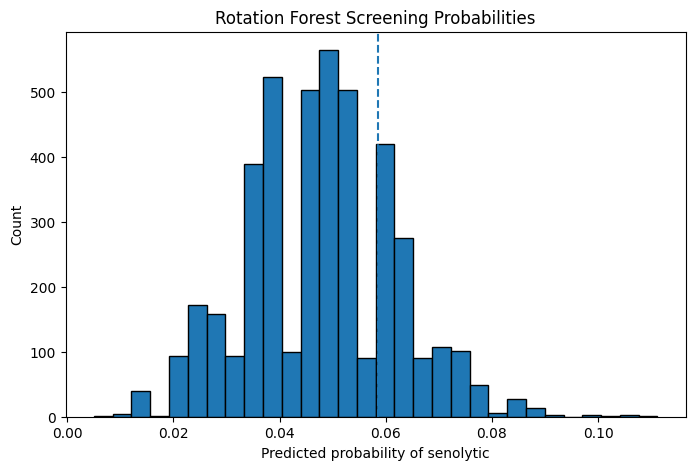

In [ ]:
# =========================================================
# 13) OPTIONAL SANITY CHECK — PROBABILITY DISTRIBUTION
# =========================================================

print(results_df["senolytic_probability"].describe())

plt.figure(figsize=(8, 5))
plt.hist(results_df["senolytic_probability"], bins=30, edgecolor="black")
plt.axvline(BEST_THRESHOLD, linestyle="--")
plt.title("Rotation Forest Screening Probabilities")
plt.xlabel("Predicted probability of senolytic")
plt.ylabel("Count")
plt.show()